In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [14]:
# 2.1 理论计算题
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
dot_product = np.dot(a, b)
print(f"1. 向量点积 a·b = {dot_product}")

# 矩阵乘法
A = np.array([[1,0,2],
              [-1,3,1],])
B = np.array([[2,1],
              [0,-1],
              [3,2]])
C = A @ B
print(f"2. A×B 的形状: {C.shape}\n结果矩阵:\n{C}")

frob_a = np.linalg.norm(a)
print(f"3. 向量 a 的 Frobenius 范数: {frob_a:.4f} (即 √14 ≈ 3.7417)")

1. 向量点积 a·b = -8
2. A×B 的形状: (2, 2)
结果矩阵:
[[ 8  5]
 [ 1 -2]]
3. 向量 a 的 Frobenius 范数: 3.7417 (即 √14 ≈ 3.7417)


In [5]:
# 2.2 编程题
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y
print("Z = X @ Y =\n", Z)
print("Z 的第一行第二列元素:", Z[0, 1])
print("Z 的第2行所有元素:", Z[1, :])
frob_Z = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", frob_Z)

Z = X @ Y =
 [[-1.13734789 -1.13734789]
 [-3.57601707 -3.57601707]
 [-1.34200489 -1.34200489]]
Z 的第一行第二列元素: -1.137347890675117
Z 的第2行所有元素: [-3.57601707 -3.57601707]
Z 的 Frobenius 范数: 5.636033250445746


In [6]:
# 3.1 贝叶斯公式
P_D = 0.001
P_T_given_D = 0.99
P_T_given_notD = 0.02
P_notD = 1 - P_D
P_D_given_T = (P_T_given_D * P_D) / (P_T_given_D * P_D + P_T_given_notD * P_notD)
print(f"检测为阳性时真正患病的概率: {P_D_given_T:.4f} ({P_D_given_T*100:.2f}%)")

检测为阳性时真正患病的概率: 0.0472 (4.72%)


d:\Anaconda3\envs\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from fon

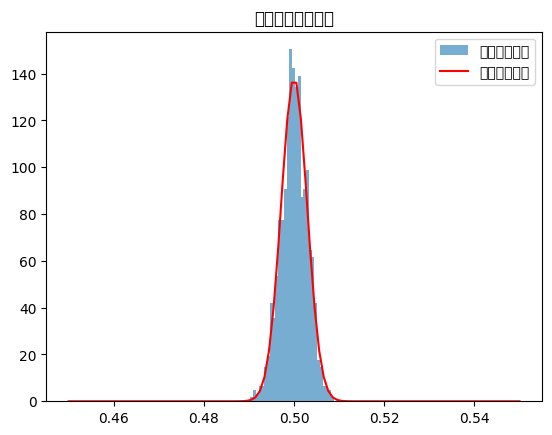

实际方差: 0.000009 (理论方差: 0.000008)


In [7]:
# 3.2 中心极限定理模拟
n = 10000
m = 1000
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

plt.hist(means, bins=30, density=True, alpha=0.6, label='样本均值分布')
mu_theory = 0.5
var_theory = (1/12) / n
x_vals = np.linspace(0.45, 0.55, 100)
plt.plot(x_vals, norm.pdf(x_vals, mu_theory, np.sqrt(var_theory)), 'r-', label='理论正态分布')
plt.legend()
plt.title("中心极限定理验证")
plt.show()

actual_var = np.var(means)
print(f"实际方差: {actual_var:.6f} (理论方差: {var_theory:.6f})")

In [8]:
# 4.1 梯度计算
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1
u = w1*x1 + w2*x2 - y
grad_w1 = 2 * u * x1
grad_w2 = 2 * u * x2
print(f"∂z/∂w1 = {grad_w1}, ∂z/∂w2 = {grad_w2}")

∂z/∂w1 = -4.0, ∂z/∂w2 = -2.0


In [9]:
# 4.2 手动反向传播 vs torch.autograd
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

a = x * w1
b = a + w2
L = b ** 2
L.backward()

print(f"自动求导: dL/dw1 = {w1.grad.item():.4f}, dL/dw2 = {w2.grad.item():.4f}")

# 手动验证
b_val = (x * w1 + w2).item()
grad_w1_manual = 2 * b_val * x.item()
grad_w2_manual = 2 * b_val * 1
print(f"手动计算: dL/dw1 = {grad_w1_manual:.4f}, dL/dw2 = {grad_w2_manual:.4f}")

自动求导: dL/dw1 = 14.0000, dL/dw2 = 7.0000
手动计算: dL/dw1 = 14.0000, dL/dw2 = 7.0000


In [10]:
# 5.1 理论推导（打印表达式）
print("∂L/∂w = -2/n * Σ x_i (y_i - w x_i - b)")
print("∂L/∂b = -2/n * Σ (y_i - w x_i - b)")

∂L/∂w = -2/n * Σ x_i (y_i - w x_i - b)
∂L/∂b = -2/n * Σ (y_i - w x_i - b)


In [11]:
# 5.2 Softmax 回归 from scratch
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

input_dim = X_train.shape[1]
num_classes = 10
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros(num_classes)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

batch_size = 32
lr = 0.1
epochs = 50
num_samples = X_train.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(num_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    for i in range(0, num_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        logits = X_batch @ W + b
        probs = softmax(logits)
        grad_logits = probs - y_batch
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0)
        W -= lr * grad_W
        b -= lr * grad_b
    if epoch % 10 == 0:
        logits_test = X_test @ W + b
        pred_test = np.argmax(softmax(logits_test), axis=1)
        acc = np.mean(pred_test == y_test)
        print(f"Epoch {epoch:2d}, test accuracy: {acc:.4f}")

# 最终准确率
logits_test = X_test @ W + b
pred_test = np.argmax(softmax(logits_test), axis=1)
final_acc = np.mean(pred_test == y_test)
print(f"Final test accuracy: {final_acc:.4f}")

Epoch  0, test accuracy: 0.8917
Epoch 10, test accuracy: 0.9694
Epoch 20, test accuracy: 0.9750
Epoch 30, test accuracy: 0.9639
Epoch 40, test accuracy: 0.9667
Final test accuracy: 0.9667


In [12]:
# 6.1 最大似然估计（打印结论）
print("1. 似然函数: L(μ,σ²) = (2πσ²)^{-n/2} exp(-1/(2σ²) Σ(x_i-μ)²)")
print("2. μ̂ = (1/n) Σ x_i")
print("3. σ̂² = (1/n) Σ (x_i - μ̂)²")

1. 似然函数: L(μ,σ²) = (2πσ²)^{-n/2} exp(-1/(2σ²) Σ(x_i-μ)²)
2. μ̂ = (1/n) Σ x_i
3. σ̂² = (1/n) Σ (x_i - μ̂)²


Iter   0, loss = 0.7044
Iter 200, loss = 0.3690
Iter 400, loss = 0.3663
Iter 600, loss = 0.3660
Iter 800, loss = 0.3659


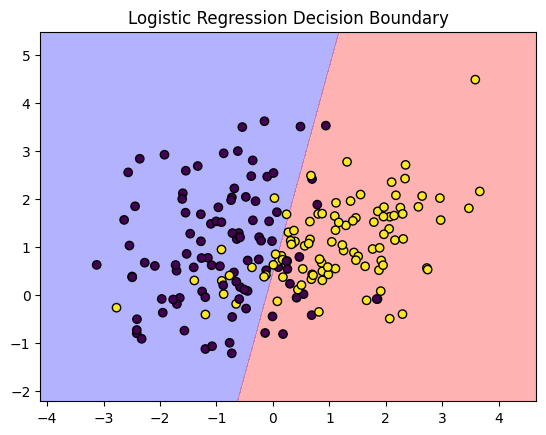

Test accuracy: 0.0200


In [13]:
# 6.2 逻辑回归二分类
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
y = y.reshape(-1, 1)

X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
theta = np.random.randn(3, 1) * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1-y_true) * np.log(1-y_pred + 1e-8))

lr = 0.1
iterations = 1000
for i in range(iterations):
    z = X_bias @ theta
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y)
    grad = X_bias.T @ (y_pred - y) / len(y)
    theta -= lr * grad
    if i % 200 == 0:
        print(f"Iter {i:3d}, loss = {loss:.4f}")

# 绘制决策边界
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_bias = np.hstack([np.ones((grid.shape[0],1)), grid])
probs = sigmoid(grid_bias @ theta).reshape(xx.shape)
plt.contourf(xx, yy, probs, levels=[0,0.5,1], alpha=0.3, colors=['blue','red'])
plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolors='k')
plt.title("Logistic Regression Decision Boundary")
plt.show()

# 测试集
X_test, y_test = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                      n_clusters_per_class=1, random_state=100)
y_test = y_test.reshape(-1,1)
X_test_bias = np.hstack([np.ones((X_test.shape[0],1)), X_test])
y_pred_test = (sigmoid(X_test_bias @ theta) >= 0.5).astype(int)
acc = np.mean(y_pred_test == y_test)
print(f"Test accuracy: {acc:.4f}")